<a href="https://colab.research.google.com/github/Srushti070/YuvaIntern-Logistics-Data-Analyst/blob/main/Week-3/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv", on_bad_lines='skip', quoting=3)

print("Orders:", orders.shape)
print("Order Items:", items.shape)

Orders: (99441, 8)
Order Items: (112650, 7)


In [6]:
date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders["late_flag"] = (orders["delay_days"] > 0).astype(int)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,late_flag
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,0


In [7]:
print(orders["delivery_days"].describe())

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64


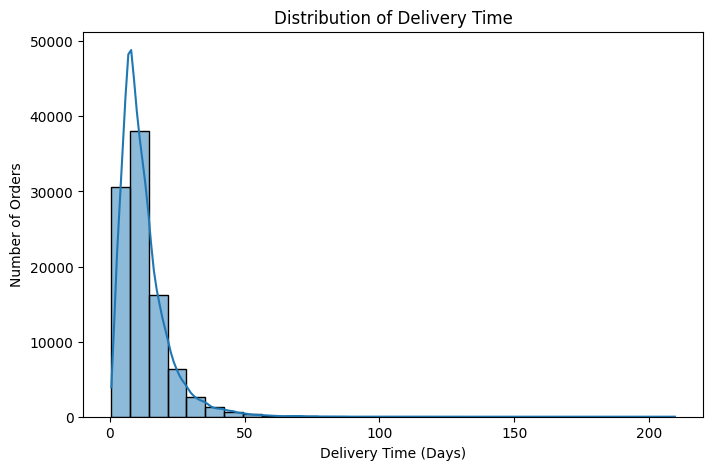

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders["delivery_days"].dropna(),
    bins=30,
    kde=True
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Time")

plt.show()

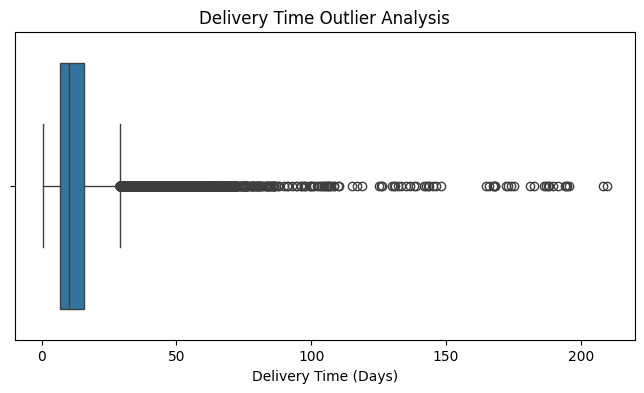

In [9]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=orders["delivery_days"].dropna()
)

plt.xlabel("Delivery Time (Days)")
plt.title("Delivery Time Outlier Analysis")

plt.show()

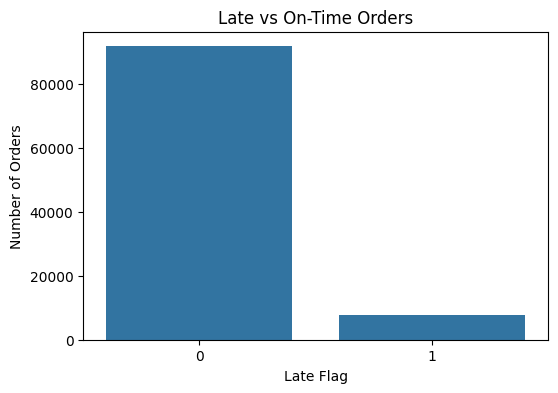

In [10]:
late_counts = orders["late_flag"].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=late_counts.index,
    y=late_counts.values
)

plt.xlabel("Late Flag")
plt.ylabel("Number of Orders")
plt.title("Late vs On-Time Orders")

plt.show()

In [12]:
# Print current column names to check for quotes or extra spaces
print("Original columns:", items.columns.tolist())

# Clean column names by stripping quotes and whitespace
items.columns = items.columns.str.replace('"', '').str.strip()
print("Cleaned columns:", items.columns.tolist())

Original columns: ['"order_id"', '"order_item_id"', '"product_id"', '"seller_id"', '"shipping_limit_date"', '"price"', '"freight_value"']
Cleaned columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


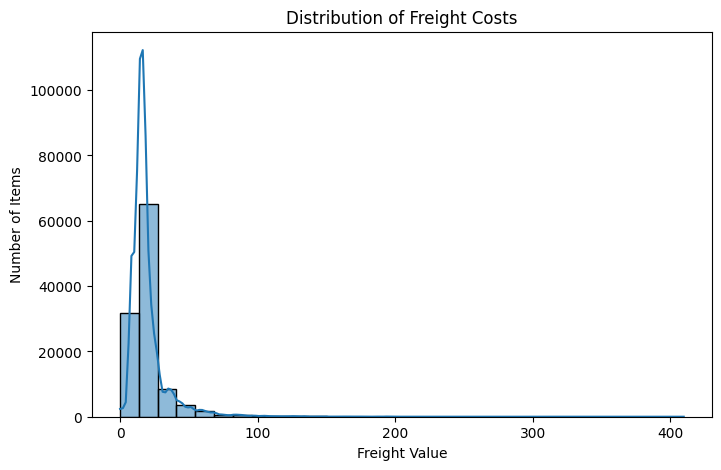

In [13]:
# Retry the distribution plot of freight value using cleaned columns
plt.figure(figsize=(8,5))
sns.histplot(
    pd.to_numeric(items["freight_value"], errors="coerce").dropna(),
    bins=30,
    kde=True
)
plt.xlabel("Freight Value")
plt.ylabel("Number of Items")
plt.title("Distribution of Freight Costs")
plt.show()

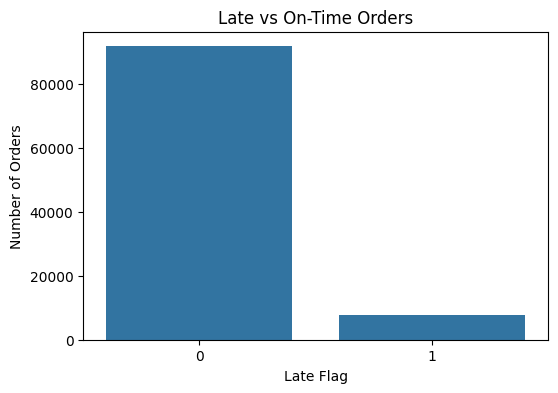

In [14]:
late_counts = orders["late_flag"].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=late_counts.index,
    y=late_counts.values
)

plt.xlabel("Late Flag")
plt.ylabel("Number of Orders")
plt.title("Late vs On-Time Orders")

plt.show()

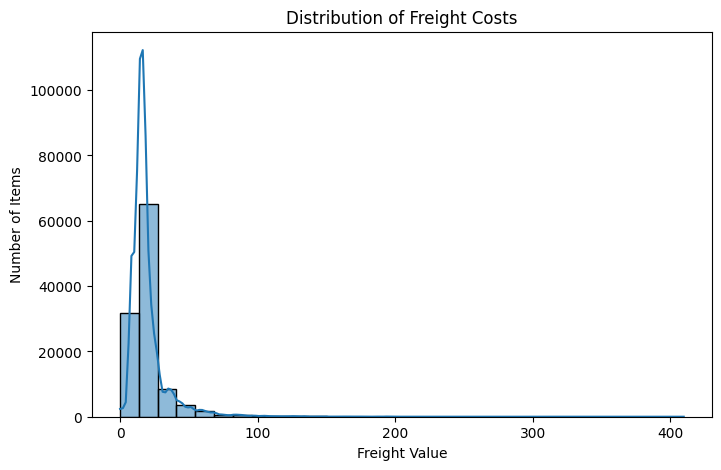

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    items["freight_value"],
    bins=30,
    kde=True
)

plt.xlabel("Freight Value")
plt.ylabel("Number of Items")
plt.title("Distribution of Freight Costs")

plt.show()

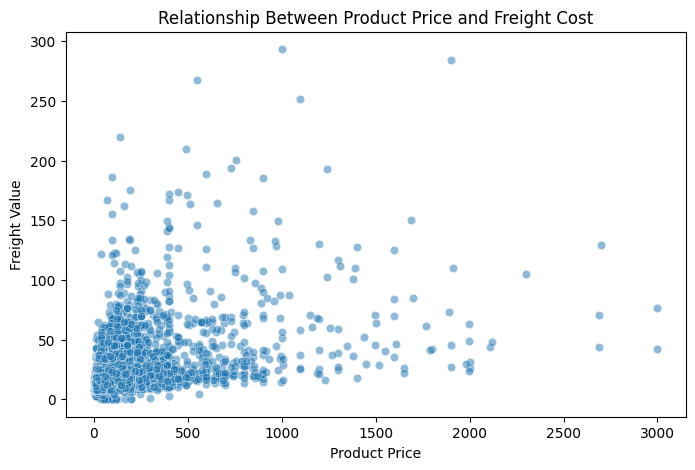

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=items.sample(min(10000, len(items))),
    x="price",
    y="freight_value",
    alpha=0.5
)

plt.xlabel("Product Price")
plt.ylabel("Freight Value")
plt.title("Relationship Between Product Price and Freight Cost")

plt.show()

                  price  freight_value
price          1.000000       0.414204
freight_value  0.414204       1.000000


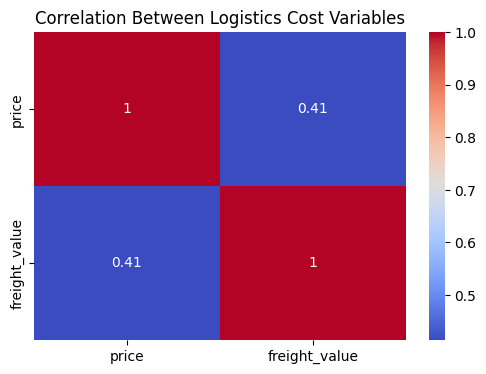

In [17]:
numeric_data = items[
    ["price", "freight_value"]
]

correlation = numeric_data.corr()

print(correlation)

plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Logistics Cost Variables")

plt.show()

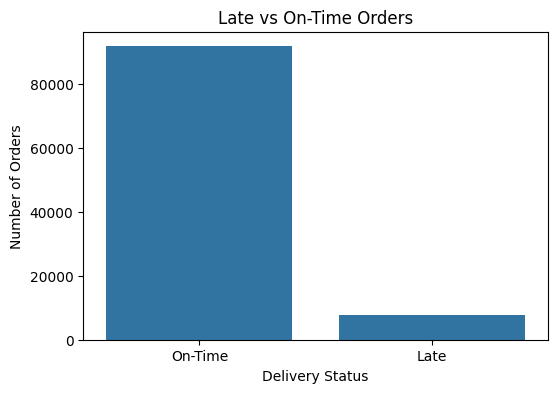

In [18]:
late_counts = orders["late_flag"].map({
    0: "On-Time",
    1: "Late"
}).value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=late_counts.index,
    y=late_counts.values
)

plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.title("Late vs On-Time Orders")

plt.show()

In [19]:
total_orders = len(orders)

on_time = (orders["late_flag"] == 0).sum()
late = (orders["late_flag"] == 1).sum()

on_time_percentage = (on_time / total_orders) * 100
late_percentage = (late / total_orders) * 100

print("Total Orders:", total_orders)
print("On-Time Orders:", on_time)
print("Late Orders:", late)

print(f"On-Time Percentage: {on_time_percentage:.2f}%")
print(f"Late Percentage: {late_percentage:.2f}%")

print(f"Average Delivery Time: {orders['delivery_days'].mean():.2f} days")
print(f"Median Delivery Time: {orders['delivery_days'].median():.2f} days")
print(f"Maximum Delivery Time: {orders['delivery_days'].max():.2f} days")

print(
    f"Price-Freight Correlation: "
    f"{items[['price','freight_value']].corr().loc['price','freight_value']:.2f}"
)

Total Orders: 99441
On-Time Orders: 91614
Late Orders: 7827
On-Time Percentage: 92.13%
Late Percentage: 7.87%
Average Delivery Time: 12.56 days
Median Delivery Time: 10.22 days
Maximum Delivery Time: 209.63 days
Price-Freight Correlation: 0.41
